# SWR-triggered current source density tutorial

Compute a channel-by-time CSD average around pre-computed sharp-wave ripple (SWR) events. The session path matches `lfp_loader_tutorial.ipynb`.


In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nelpy as nel
import numpy as np

import neuro_py as npy

npy.plotting.set_plotting_defaults()


## 1. Set the session path

This session is expected to contain the pre-computed `basename.ripples.events.mat` file read by `npy.io.load_ripples_events`.


In [2]:
basepath = r"Z:\Data\AYAold\AB4\day03"

## 2. Load SWR epochs

The event file supplies each SWR's start, stop, and peak time. Peaks provide a common alignment point for averaging the LFP and CSD.


In [3]:
ripples = npy.io.load_ripples_events(basepath)
if ripples.empty:
    raise FileNotFoundError("No ripples.events.mat file was found for this session.")

ripples = nel.EventArray(abscissa_vals=ripples.peaks.to_numpy(), fs=1250)

# restrict to nrem sleep
nrem = npy.io.load_SleepState_states(basepath, return_epoch_array=True).get("NREMstate")
ripples = ripples[nrem]

## 3. Load all channels from all shank

CSD requires several depth-ordered channels. The probe layout selects one shank and supplies its physical channel order and spacing.


In [4]:
probe_layout = npy.io.load_probe_layout(basepath)

# remove last shank here as it contains accelerometer channels (***specific for this basepath***)
shank_layout = probe_layout.query("shank < 8")

bad_channels = npy.io.load_channel_tags(basepath).get("Bad", [])
if bad_channels:
    if bad_channels:
        bad_channels = bad_channels.get("channels", [])

    # normalize to a list for pandas .query / isin semantics
    if isinstance(bad_channels, np.ndarray):
        bad_channels = np.array(bad_channels) - 1
    elif isinstance(bad_channels, (np.integer, int)):
        bad_channels = [int(np.array(bad_channels) - 1)]
    elif bad_channels is None:
        bad_channels = []

    shank_layout = shank_layout.query("channels not in @bad_channels")

channels = shank_layout.channels.to_list()


In [5]:
lfp = npy.io.LFPLoader(
    basepath,
    channels=channels,
    ext="lfp",
    epoch=[ripples.data[0, :] - 0.15, ripples.data[0, :] + 0.15],
)
times = lfp.abscissa_vals
lfp

<LFPLoader at 0x1bc318653a0: 250 signals> for a total of 5:02:05:299 hours

## 4. Average LFP around SWR peaks

Extracting identical windows around valid ripple peaks produces a channel-by-time average that suppresses unrelated activity while retaining the ripple-associated laminar pattern.


In [6]:
avg_signal = npy.process.peth(data=lfp, events=ripples.data[0, :], window=[-0.15, 0.15])

# peth returns positional columns. Restore the physical channel IDs used by LFPLoader
# so they align with the probe-layout channel IDs below.
if avg_signal.shape[1] != len(channels):
    raise ValueError("The averaged LFP does not contain every requested channel.")
avg_signal.columns = channels

## 5. Compute and plot average CSD

The native standard CSD estimator takes the second spatial derivative across depth for each time point. Probe-layout depths are stored and plotted in micrometres, then converted to millimetres for CSD estimation. The heatmap highlights sinks and sources aligned to SWR peaks.


In [18]:


def plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="StandardCSD",
    scale_factor=0.5,
    cmap="RdBu_r",
    figsize=None,
    dpi=200,
    get_csd_kwargs=None,
):
    """
    Plot average CSD heatmaps with overlaid LFP traces, one subplot per shank,
    aligned to real channel depth.

    Parameters
    ----------
    basepath : str
        Path passed through to npy.lfp.get_csd.
    avg_signal : pd.DataFrame
        Averaged LFP, channels as columns, time as index.
    shank_layout : pd.DataFrame
        Must contain columns: shank, channels, y (depth coordinate).
    method : str, default "StandardCSD"
        CSD method passed to npy.lfp.get_csd (e.g. "StandardCSD", "DeltaiCSD", "KCSD1D").
    scale_factor : float, default 0.5
        Controls trace amplitude scaling relative to channel spacing.
        Smaller = taller traces.
    cmap : str, default "RdBu_r"
        Diverging colormap for the CSD heatmap.
    figsize : tuple, optional
        Passed to plt.subplots. Defaults to npy.plotting.set_size("nature_double") if None.
    dpi : int, default 200
        Figure DPI.
    get_csd_kwargs : dict, optional
        Extra keyword arguments forwarded to npy.lfp.get_csd (e.g. method-specific params).

    Returns
    -------
    fig, ax : matplotlib Figure and array of Axes
    """
    get_csd_kwargs = get_csd_kwargs or {}
    if figsize is None:
        figsize = npy.plotting.set_size("nature_double")

    fig, ax = plt.subplots(
        1,
        shank_layout.shank.nunique(),
        figsize=figsize,
        dpi=dpi,
    )
    # space between subplots
    fig.subplots_adjust(wspace=0.05)
    
    # ensure ax is always iterable (in case of a single shank)
    ax = np.atleast_1d(ax)

    norm = mcolors.CenteredNorm()

    all_channels = shank_layout.channels.to_list()
    global_max_amp = avg_signal.loc[:, all_channels].abs().to_numpy().max()

    min_spacing = (
        shank_layout.groupby("shank")
        .y.apply(lambda y: np.diff(np.sort(y.abs().to_numpy())).min())
        .min()
    )

    trace_scale = abs(min_spacing / (global_max_amp * scale_factor))

    im = None
    for i, shank in enumerate(shank_layout.shank.unique()):
        shank_df = shank_layout.query("shank == @shank").copy()
        shank_df["depth_um"] = shank_df.y.abs()
        shank_df = shank_df.sort_values(
            "depth_um", ascending=True
        )  # required ascending for get_csd

        channels = shank_df.channels.to_list()
        coords_mm = shank_df.depth_um.to_numpy(dtype=float) / 1000.0

        assert np.all(np.diff(coords_mm) > 0), (
            "coords must be strictly increasing for get_csd"
        )

        mean_csd = npy.lfp.get_csd(
            basepath,
            avg_signal.loc[:, channels].to_numpy().T,
            shank=shank,
            method=method,
            coords=coords_mm,
            **get_csd_kwargs,
        )

        # The second derivative has no electrode outside either boundary, so
        # StandardCSD boundary estimates are not interpretable. Keep the LFP
        # traces, but mask those two heatmap rows.
        plot_csd = mean_csd.copy()
        if method == "StandardCSD":
            plot_csd[[0, -1]] = np.nan

        # negate coords only for display positioning — shallow near 0, deep more negative,
        # so shallow renders near the top with a normal (non-inverted) y-axis.
        plot_coords = -shank_df.depth_um.to_numpy(dtype=float)

        im = ax[i].pcolormesh(
            avg_signal.index,
            plot_coords,
            plot_csd,
            cmap=cmap,
            norm=norm,
            shading="nearest",
        )

        ax[i].plot(
            avg_signal.index,
            avg_signal.loc[:, channels] * trace_scale + plot_coords,
            color="k",
            linewidth=0.6,
        )

        ax[i].set_title(f"shank {shank}")
        ax[i].set_xlabel("time (s)")
        ax[i].set_yticks([])
        ax[i].spines["left"].set_visible(False)

        ax[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda val, pos: f"{-val:.0f}")
        )

    ax[0].set_ylabel("depth (μm)")
    fig.colorbar(im, ax=ax[-1], label="CSD (a.u.)", shrink=0.6)

    return fig, ax

Text(0.5, 0.95, 'KCSD1D')

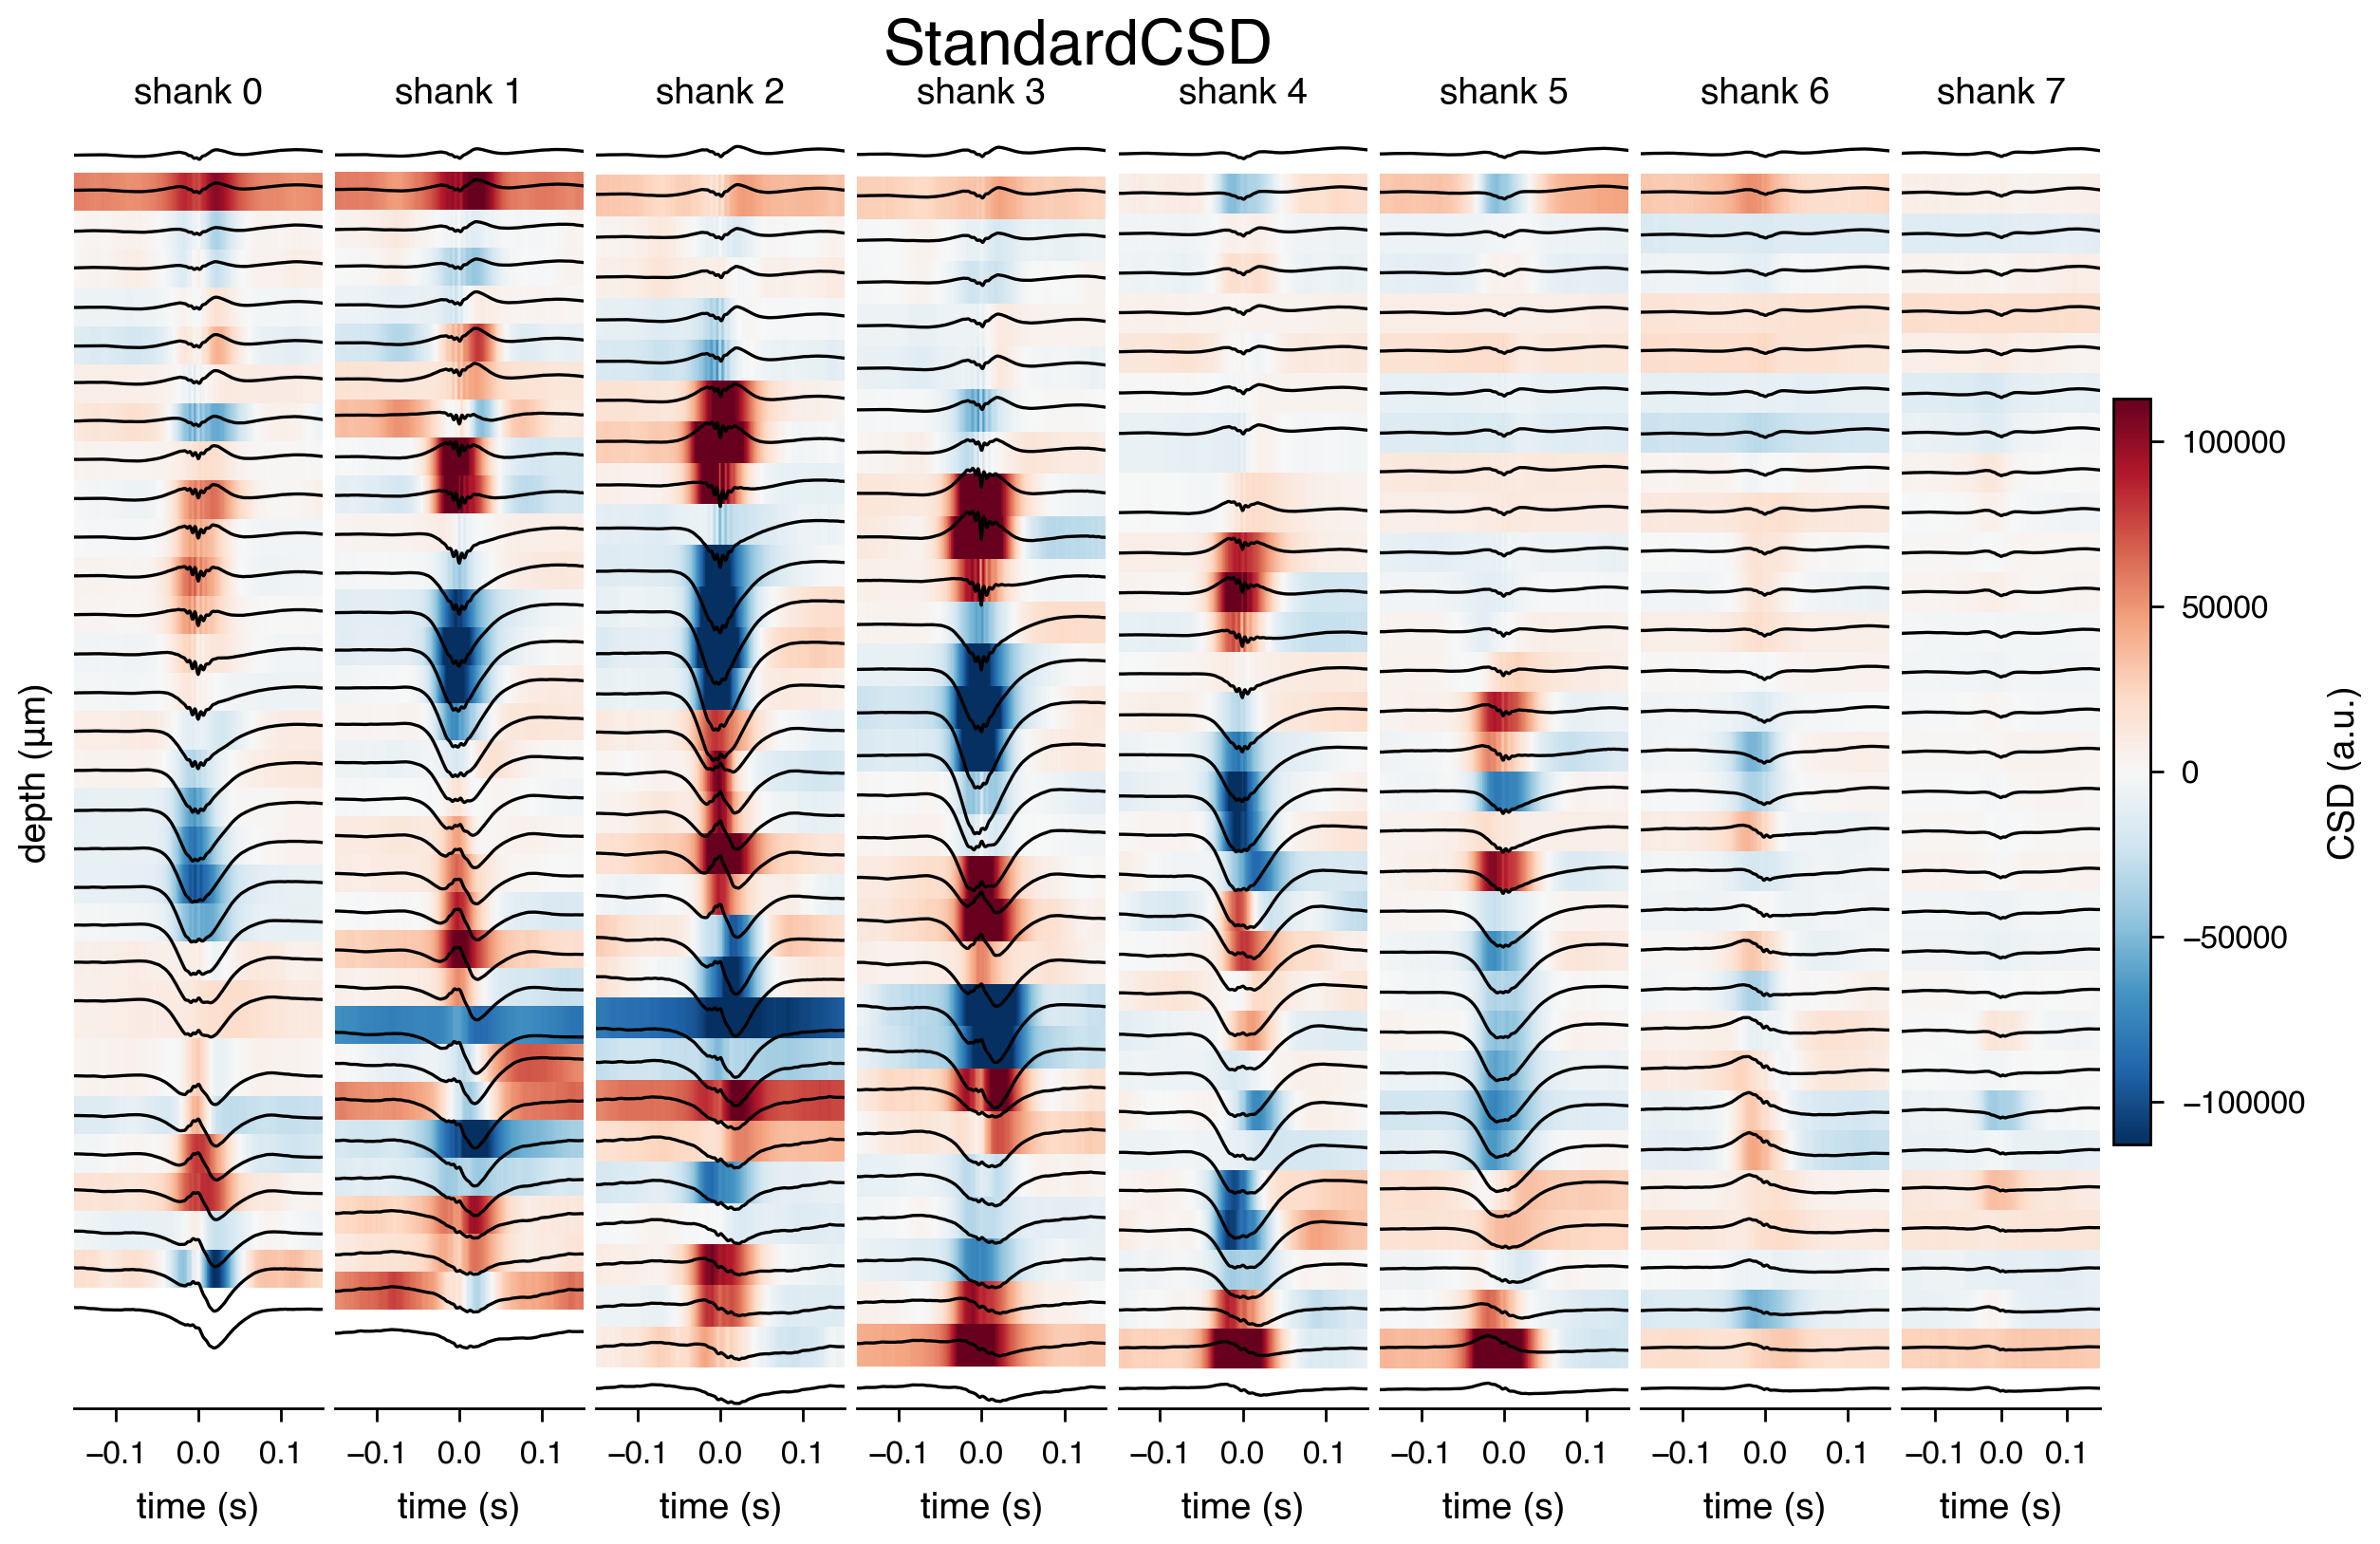

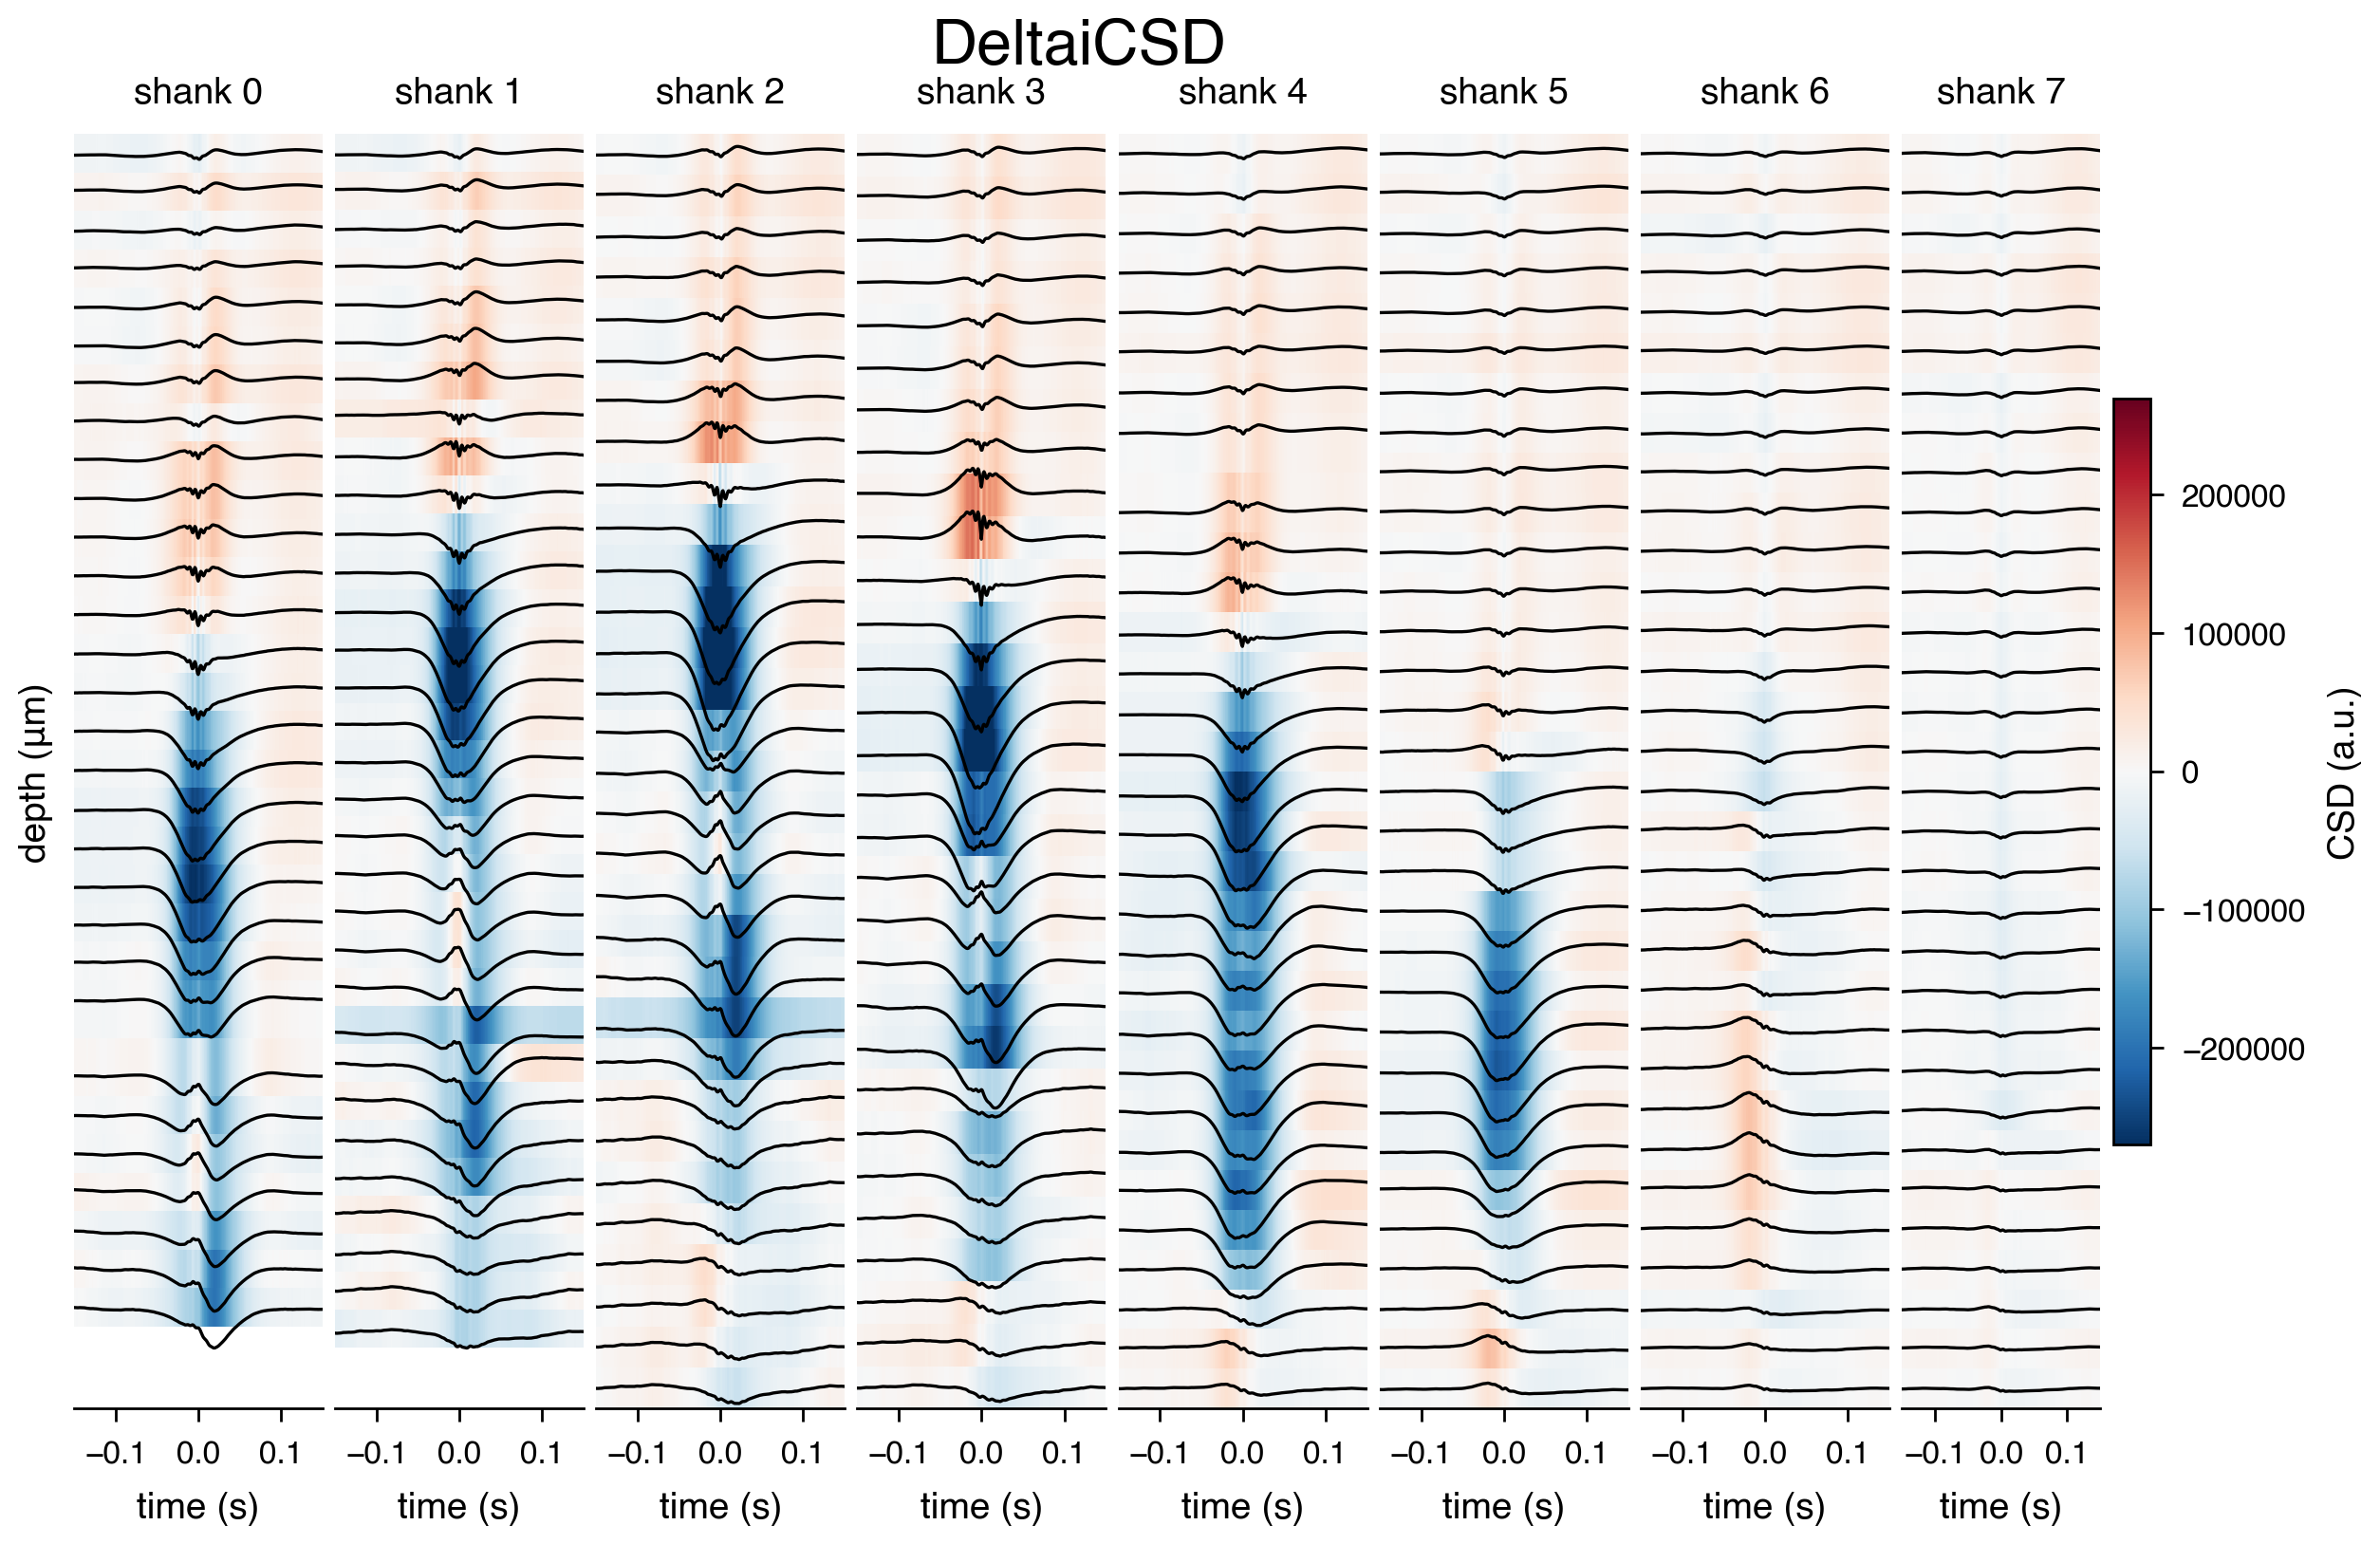

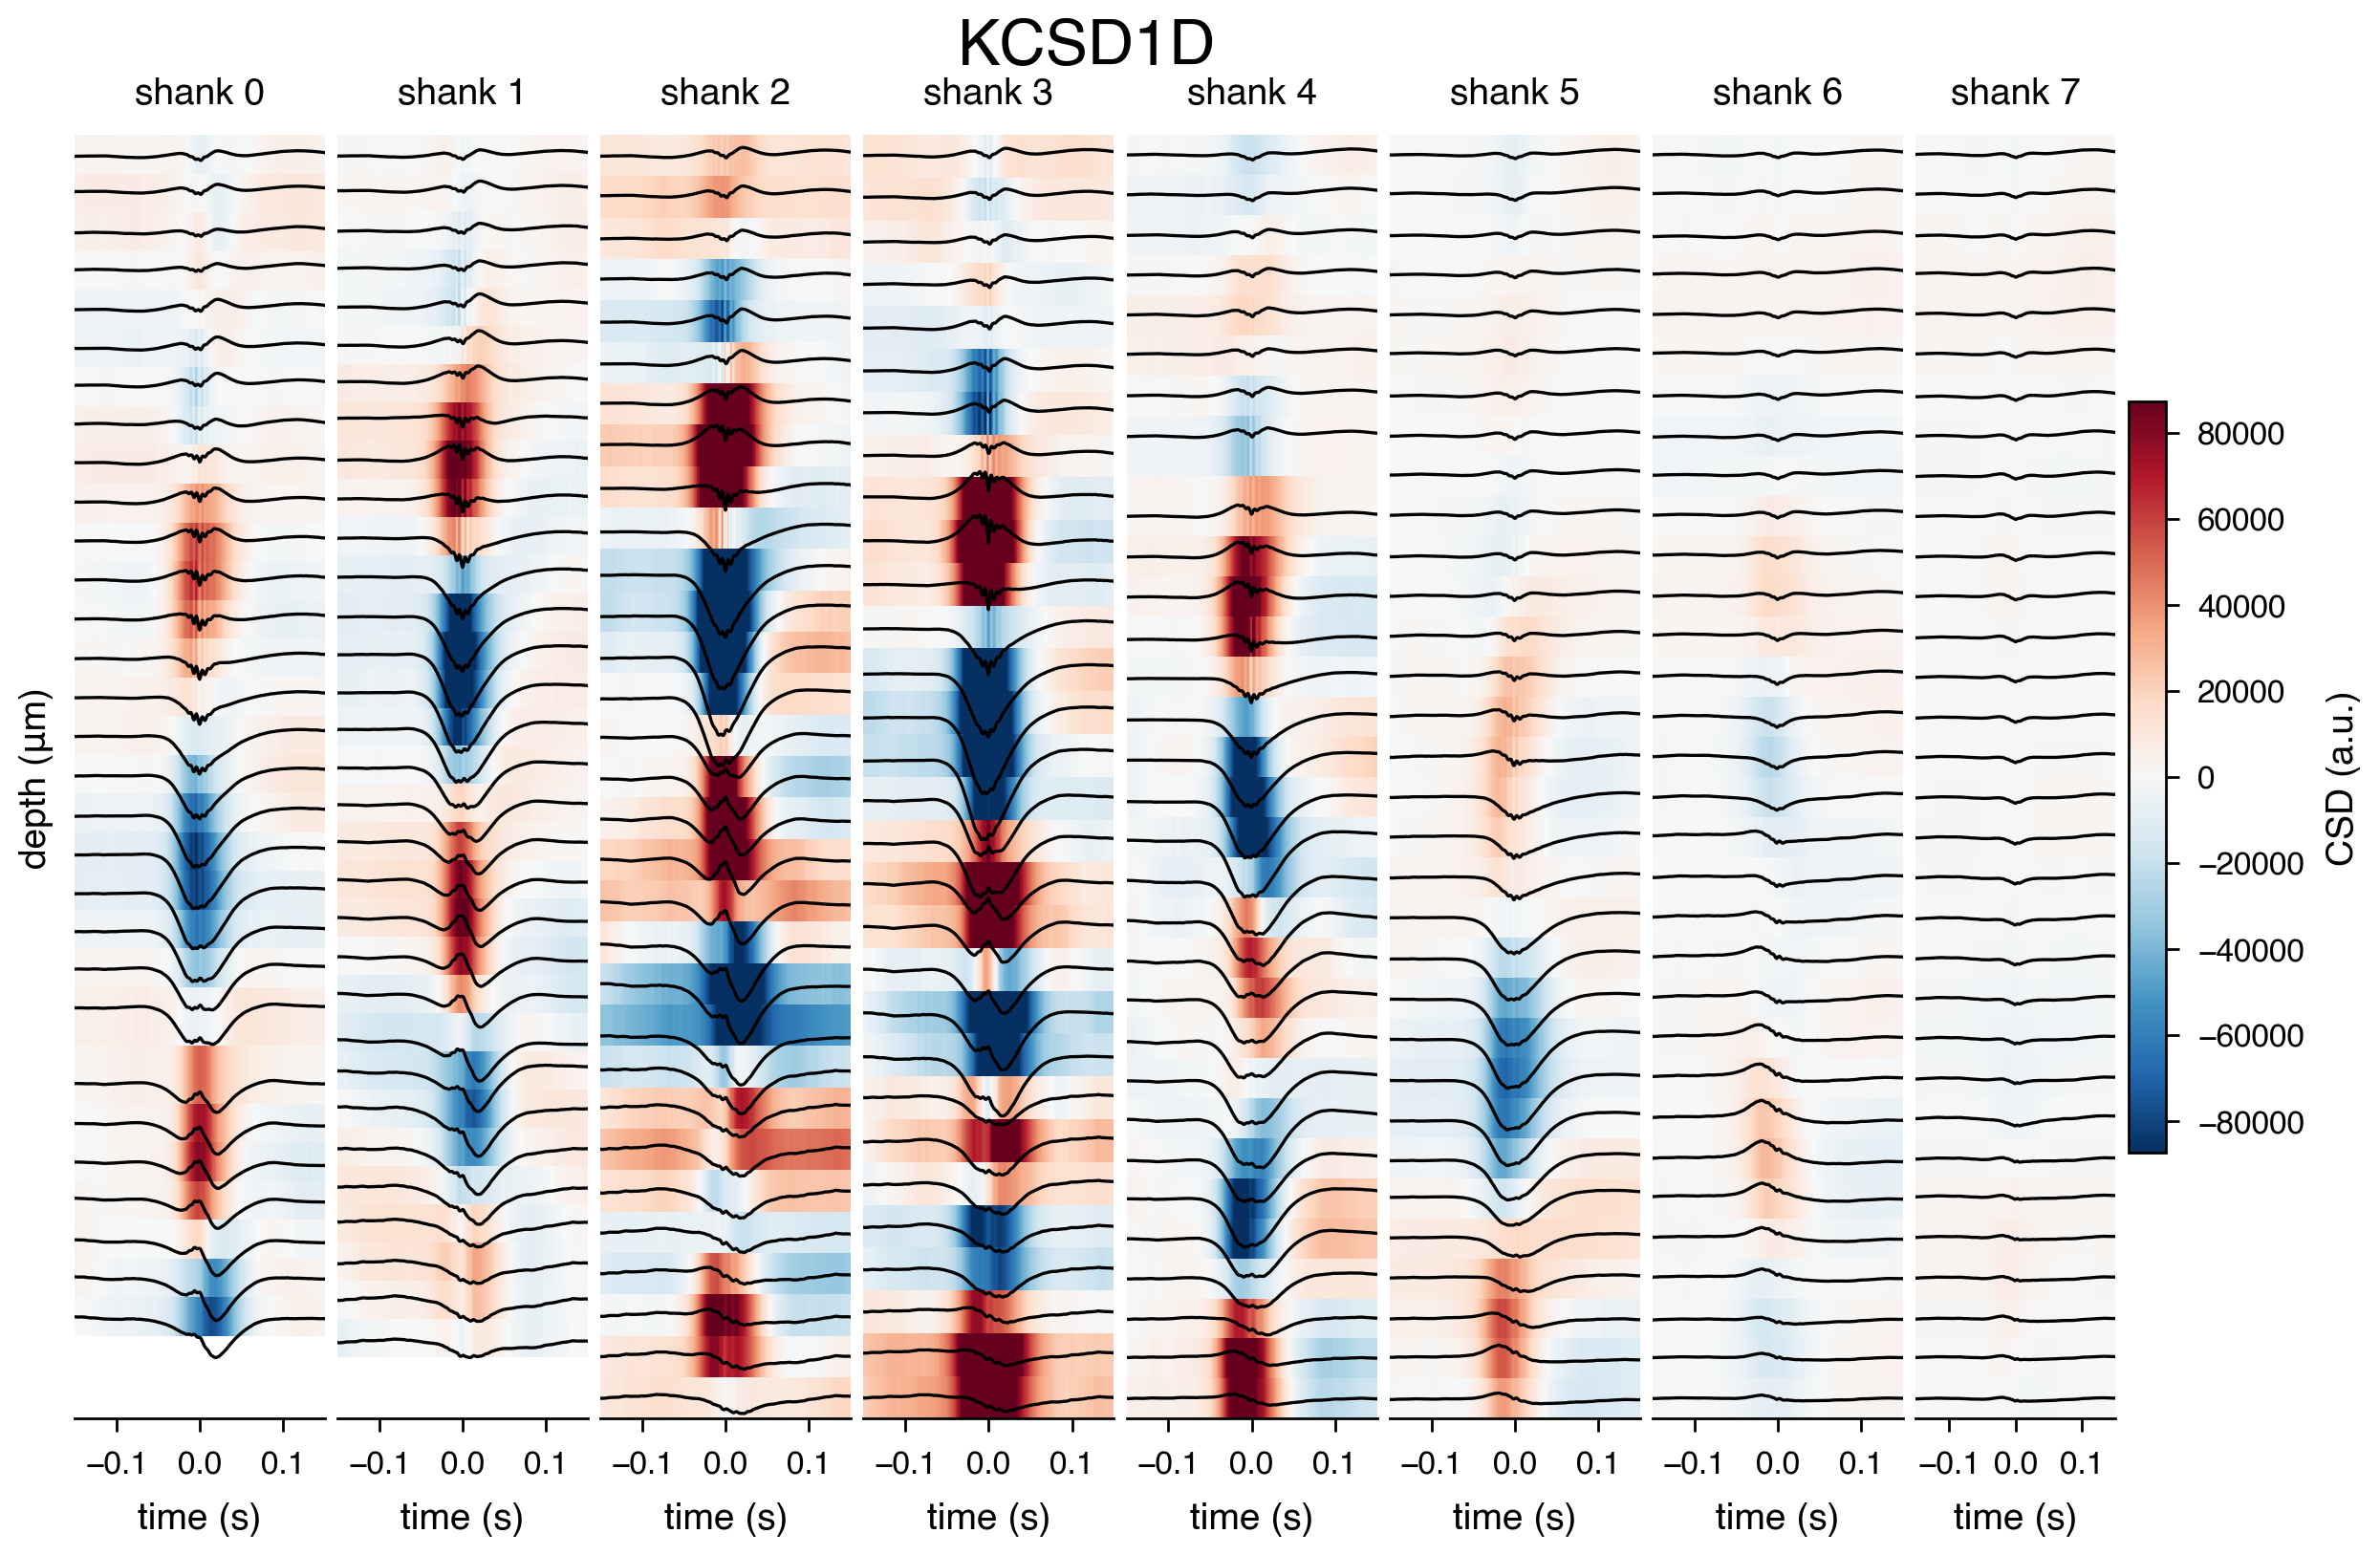

In [20]:
fig, ax = plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="StandardCSD",
)
# suplot title
fig.suptitle("StandardCSD", fontsize=12, y=0.95)

fig, ax = plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="DeltaiCSD",
)
fig.suptitle("DeltaiCSD", fontsize=12, y=0.95)

fig, ax = plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="KCSD1D",
)
fig.suptitle("KCSD1D", fontsize=12, y=0.95)

# now the same, but for Dentate spikes

In [25]:
dentate_spikes = npy.io.load_events(basepath, epoch_name="DS2",load_pandas=True)
dentate_spikes = nel.EventArray(abscissa_vals=dentate_spikes.peaks.to_numpy(), fs=1250)
dentate_spikes = dentate_spikes[nrem]
dentate_spikes

<EventArray at 0x1bc8a004710: 1 series (61 segments)> at 1250 Hz

In [29]:
lfp = npy.io.LFPLoader(
    basepath,
    channels=channels,
    ext="lfp",
    epoch=[dentate_spikes.data[0, :] - 0.1, dentate_spikes.data[0, :] + 0.1],
)
times = lfp.abscissa_vals
lfp

<LFPLoader at 0x1bc431f4aa0: 250 signals> for a total of 5:02:05:299 hours

In [30]:
avg_signal = npy.process.peth(data=lfp, events=dentate_spikes.data[0, :], window=[-0.1, 0.1])

# peth returns positional columns. Restore the physical channel IDs used by LFPLoader
# so they align with the probe-layout channel IDs below.
if avg_signal.shape[1] != len(channels):
    raise ValueError("The averaged LFP does not contain every requested channel.")
avg_signal.columns = channels

Text(0.5, 0.95, 'KCSD1D')

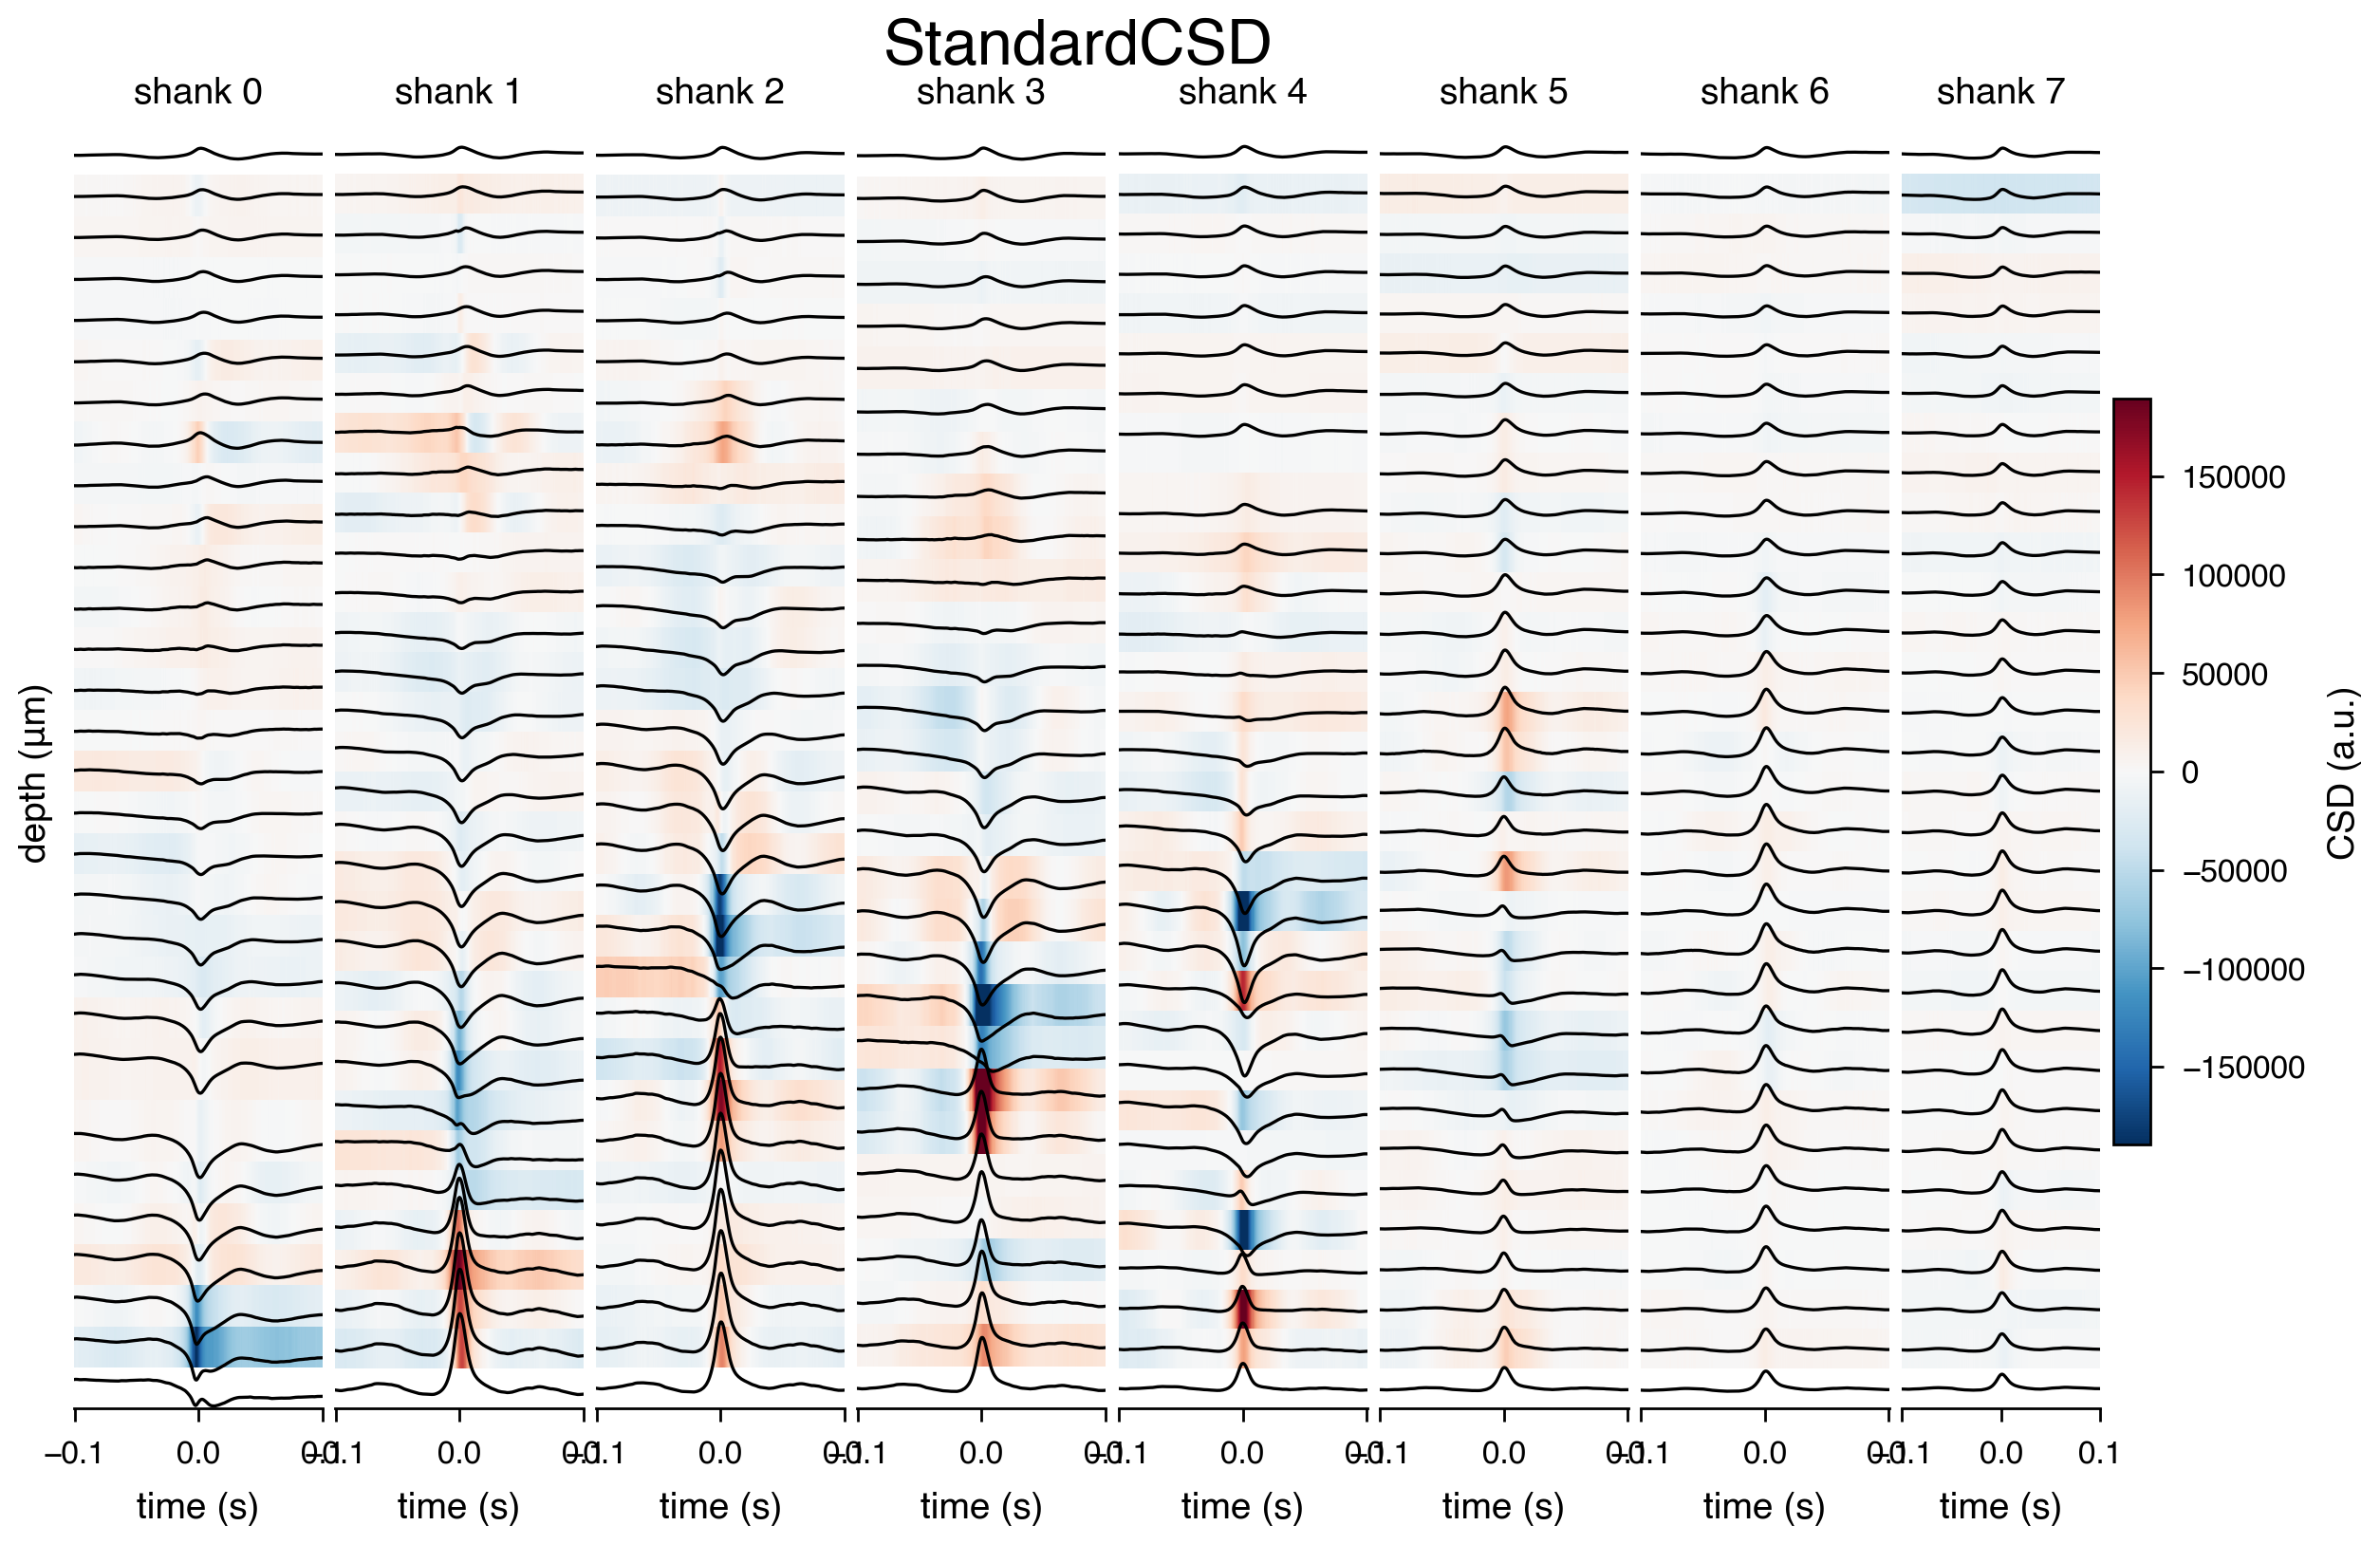

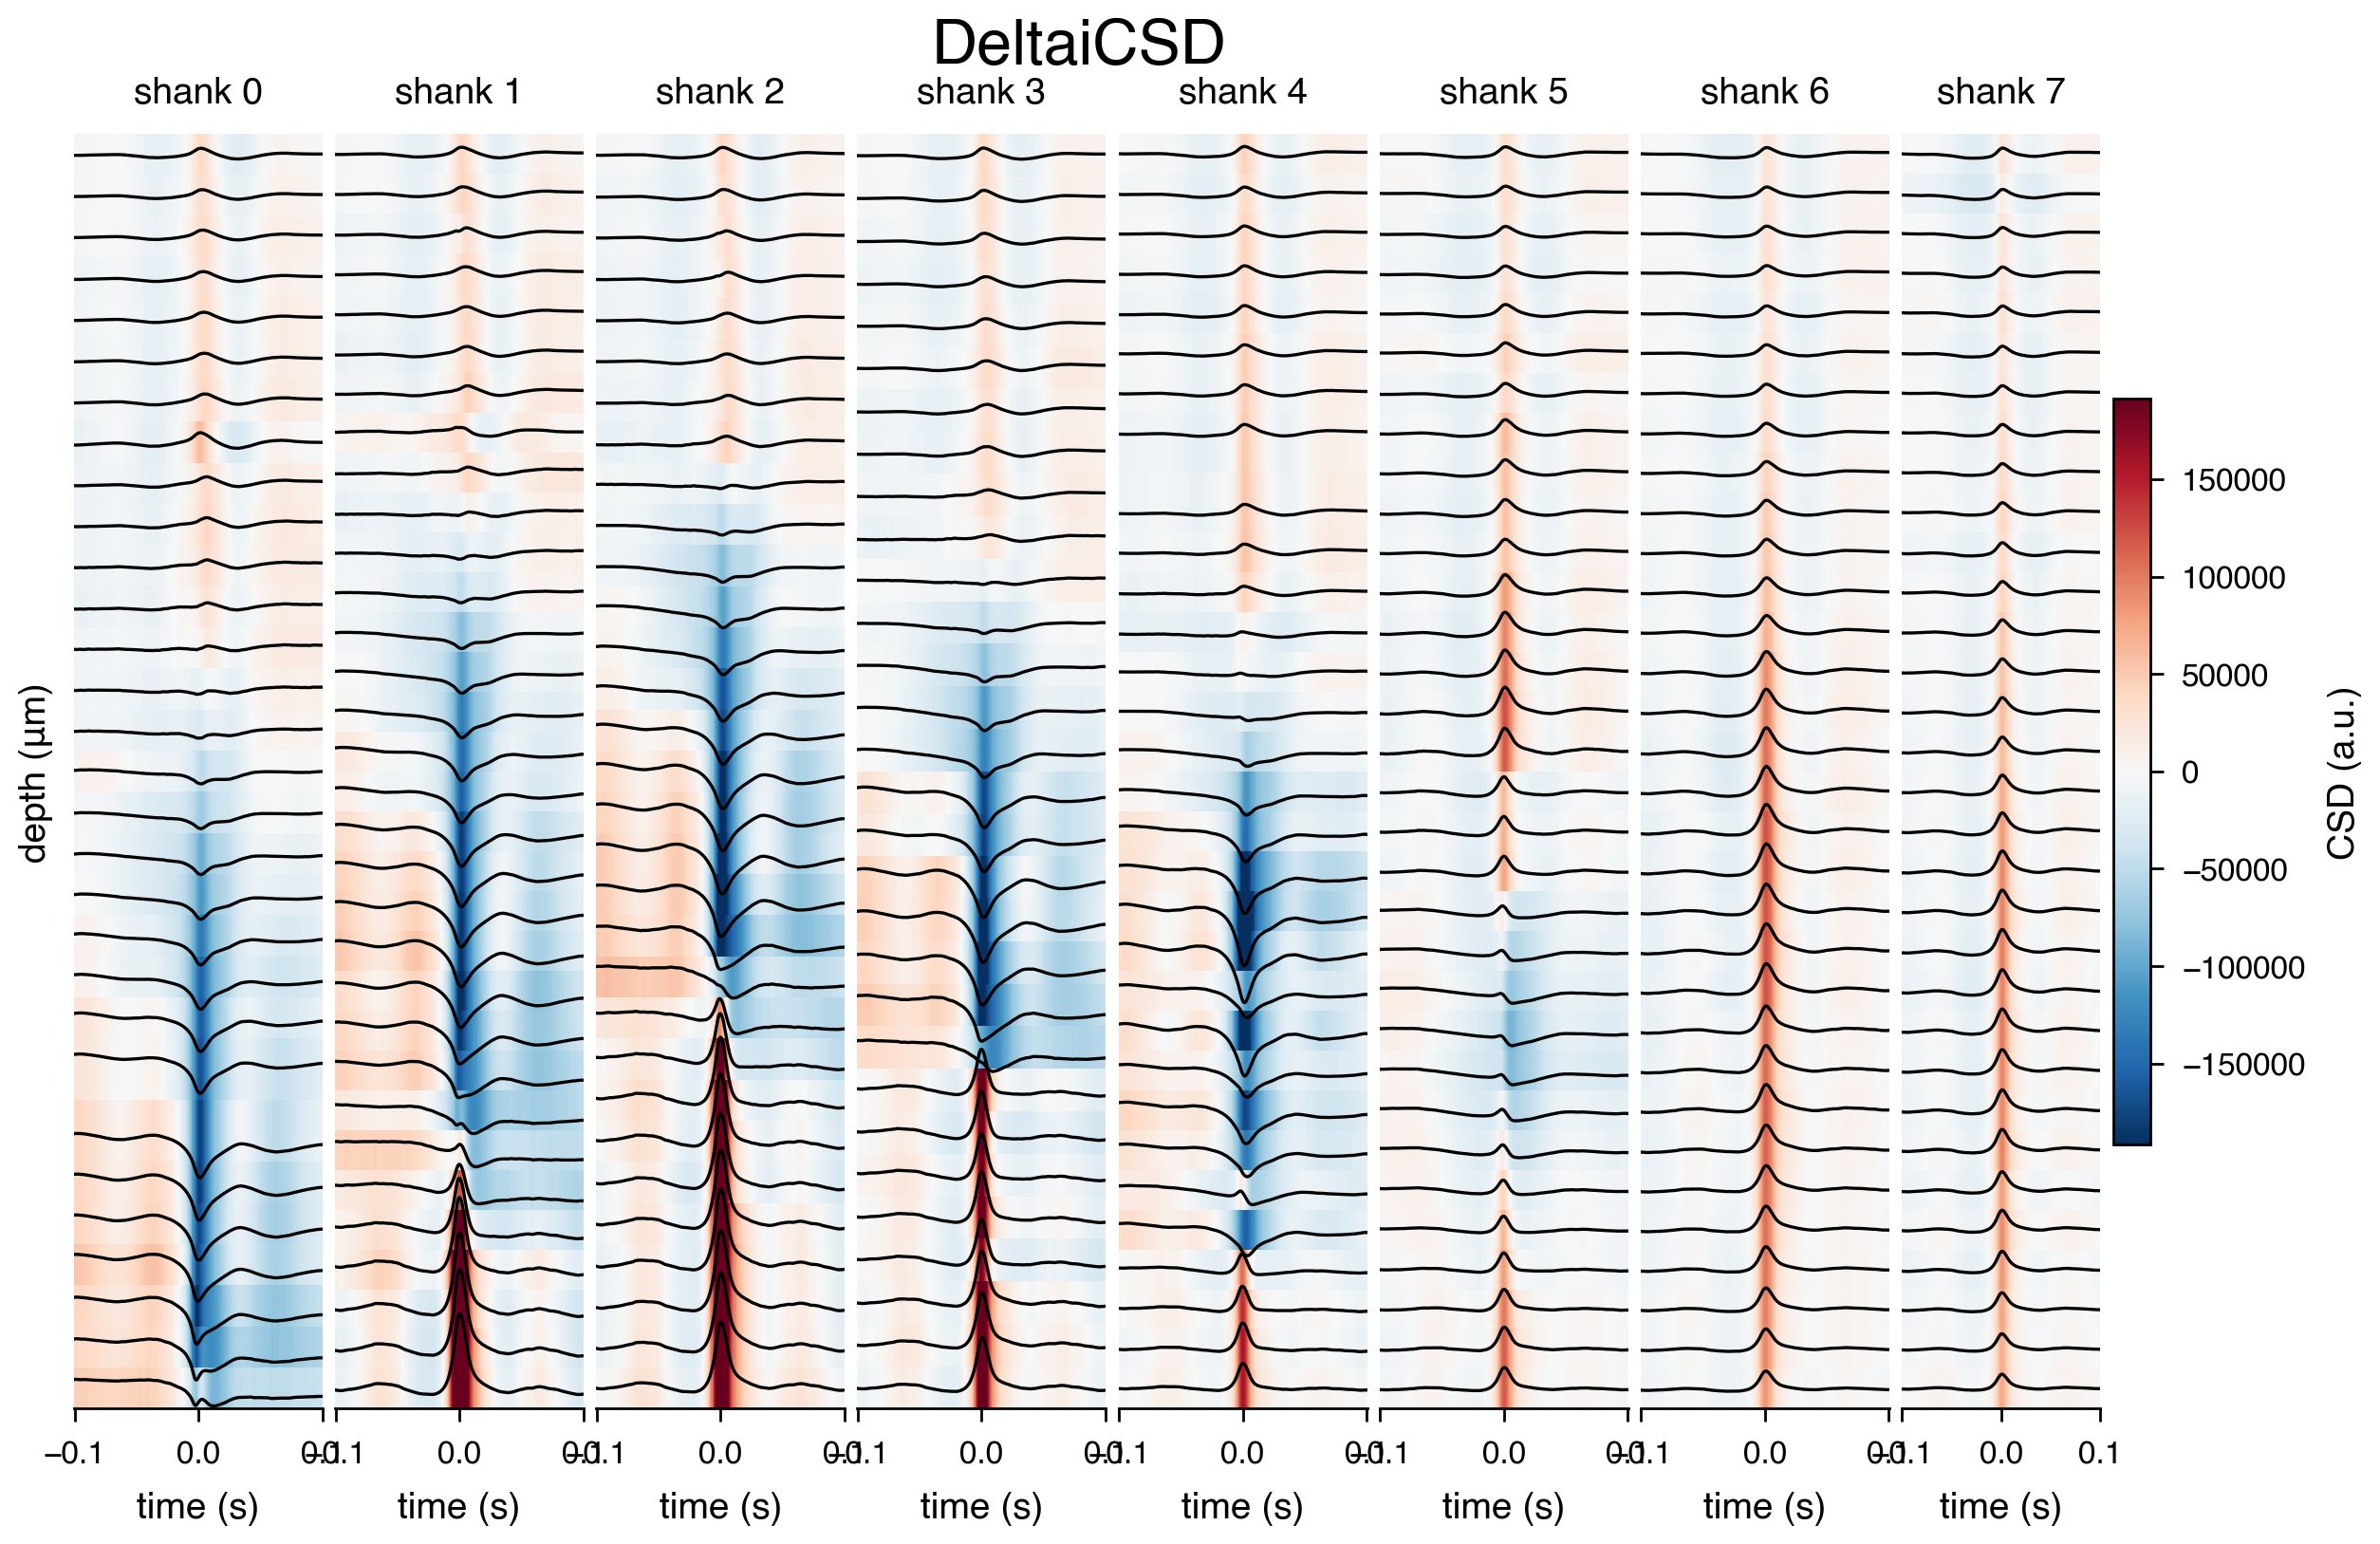

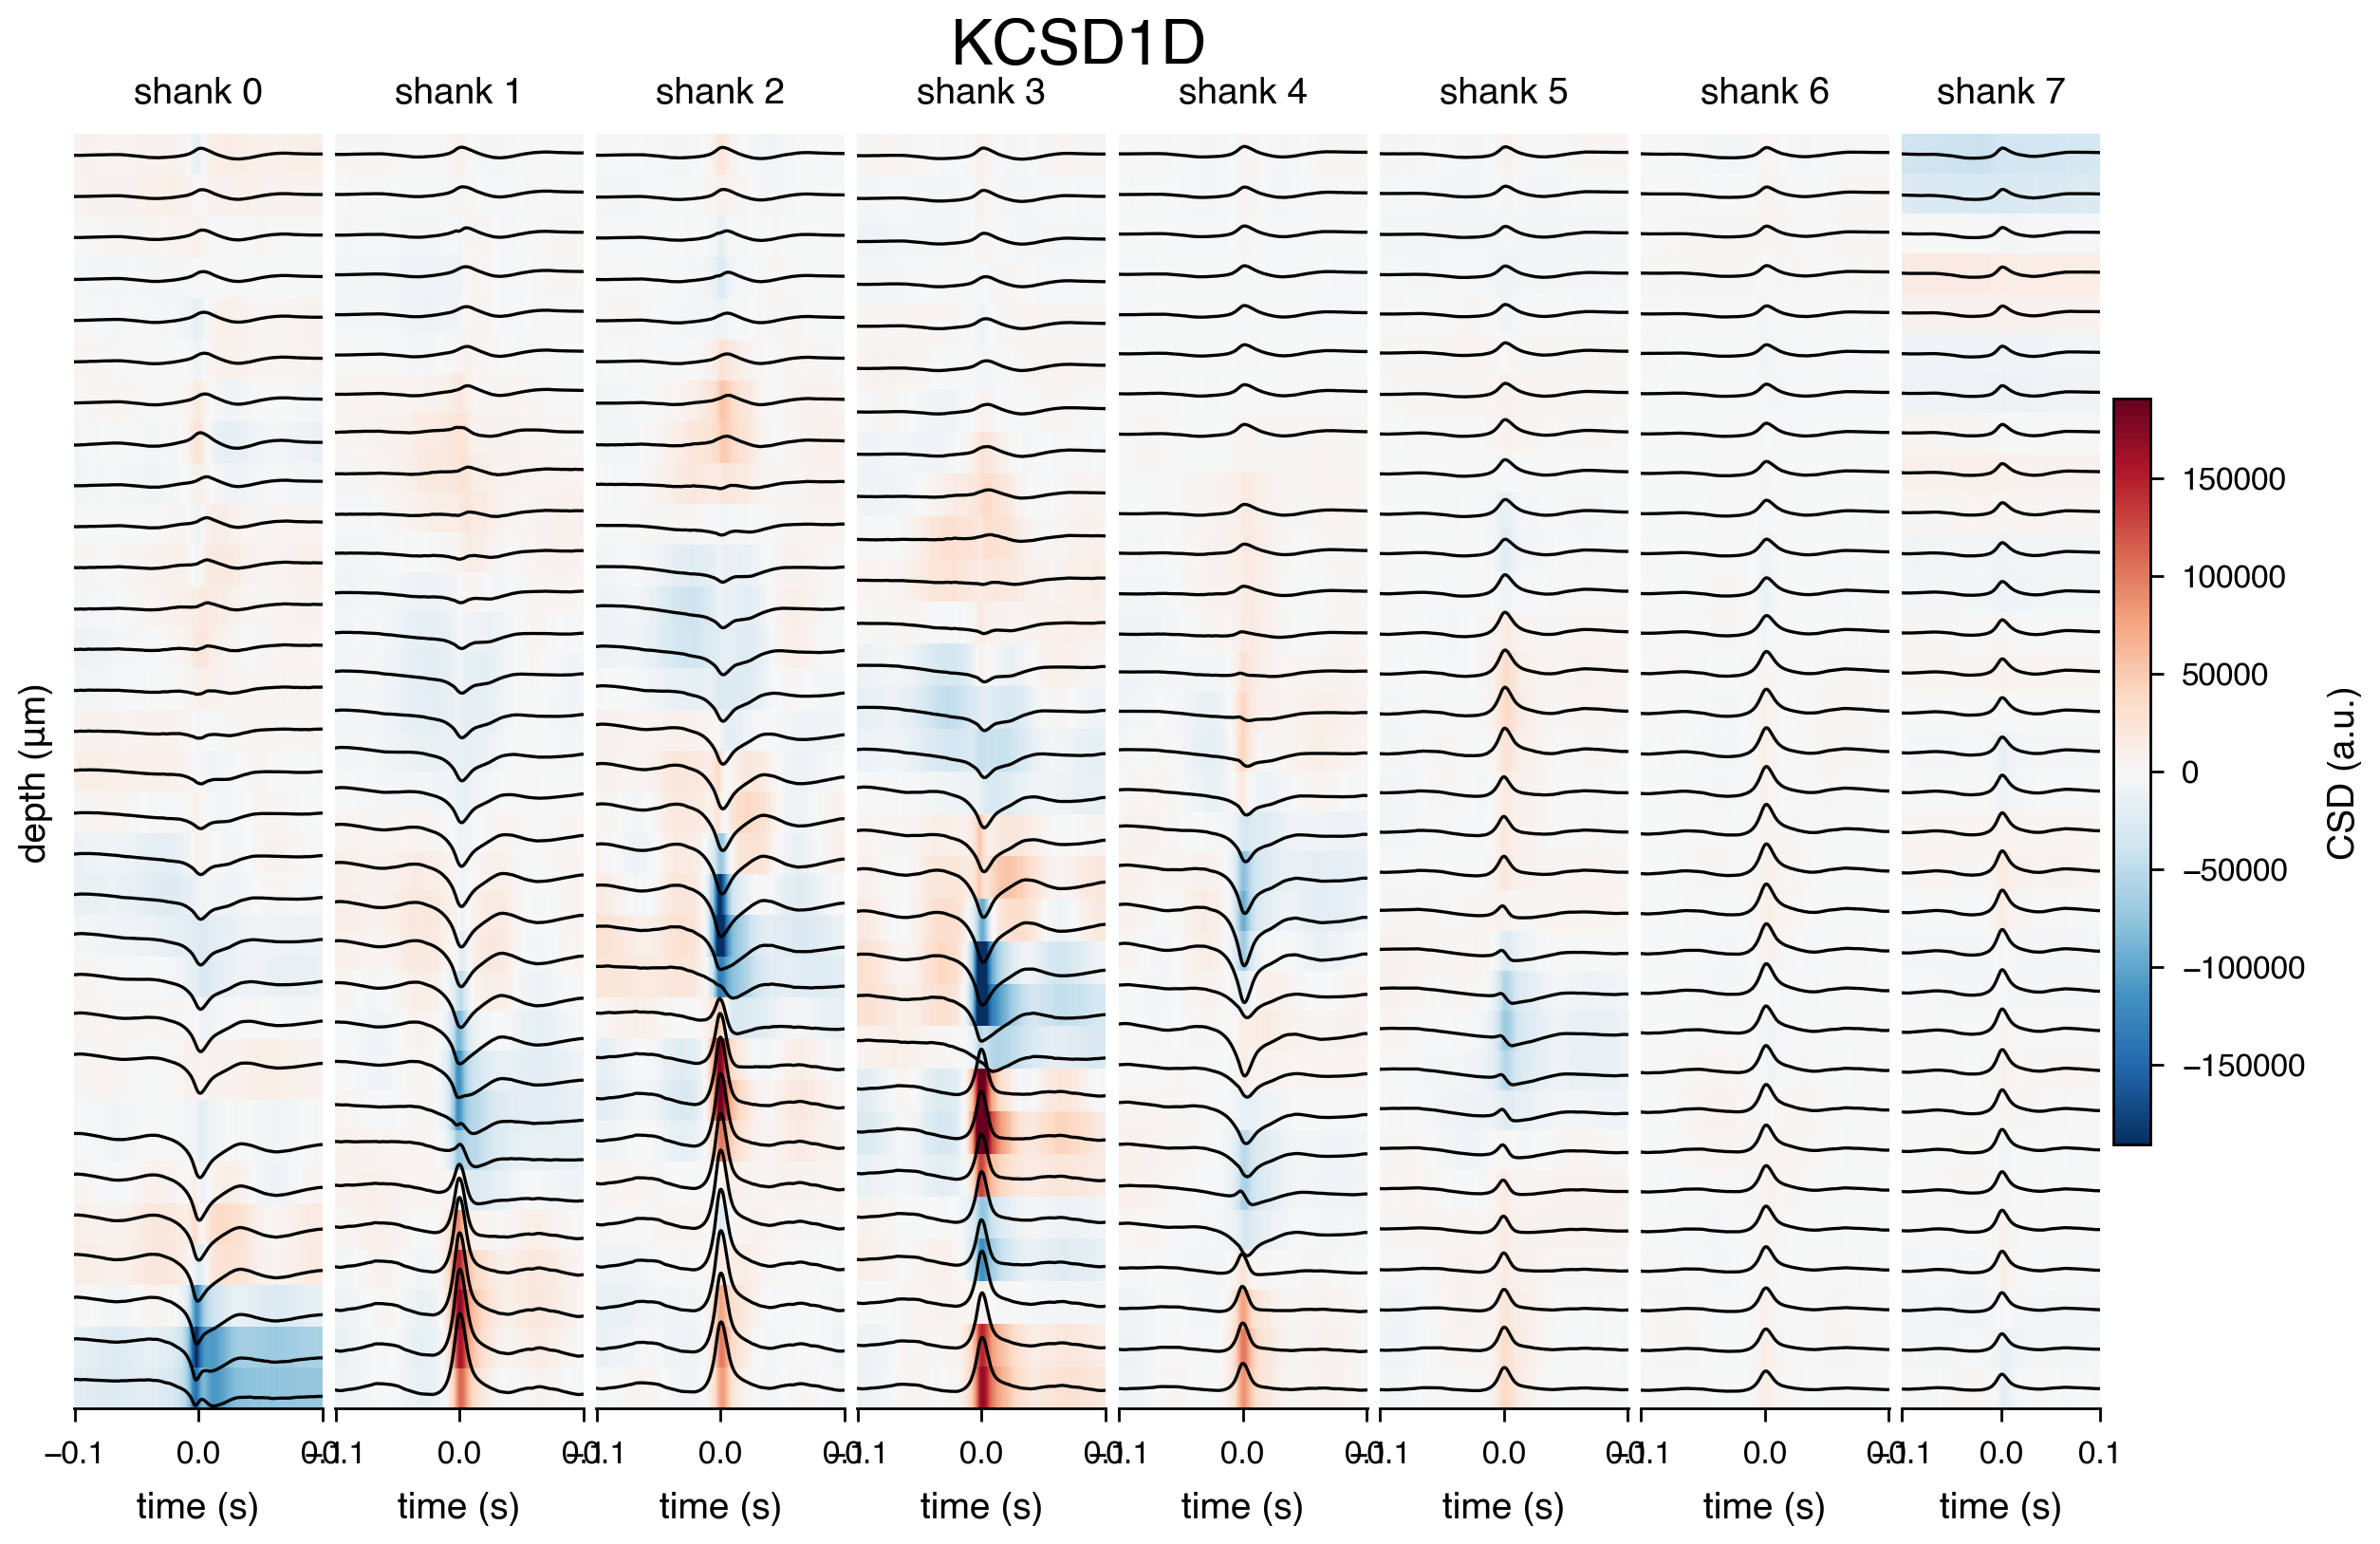

In [31]:
fig, ax = plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="StandardCSD",
)
# suplot title
fig.suptitle("StandardCSD", fontsize=12, y=0.95)

fig, ax = plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="DeltaiCSD",
)
fig.suptitle("DeltaiCSD", fontsize=12, y=0.95)

fig, ax = plot_csd_by_shank(
    basepath,
    avg_signal,
    shank_layout,
    method="KCSD1D",
)
fig.suptitle("KCSD1D", fontsize=12, y=0.95)